In [1]:
import featuregraph as fg
import matplotlib.pyplot as plt

fault_number = 2
simulation_run = 10
signal = "reactor_pressure"

df = fg.datasets.eastman(
    fault_number=fault_number,
    simulation_run=simulation_run,
)

df["sample_index"] = df.index
df["time_hours"] = df["time_(h)"]
df["reactor_pressure_raw"] = df[signal]

sample_interval_minutes = df["time_hours"].diff().median() * 60
smooth_window_minutes = 20

smooth_window_samples = round(
    smooth_window_minutes / sample_interval_minutes
)
numerical_atol = 1e-12

df["reactor_pressure_smooth"] = (
    df["reactor_pressure_raw"]
    .rolling(
        window=smooth_window_samples,
        min_periods=smooth_window_samples,
        center=True,
    )
    .mean()
)

df["reactor_pressure_change"] = (
    df["reactor_pressure_smooth"].diff()
)

df["reactor_pressure_rate"] = (
    df["reactor_pressure_smooth"].diff()
    / df["time_hours"].diff()
)

df["reactor_pressure_valid"] = (
    df["reactor_pressure_smooth"].notna()
    & df["reactor_pressure_rate"].notna()
)

valid = df["reactor_pressure_valid"]

rate_eps = 0.75  # pressure units per hour

df["reactor_pressure_rising"] = (
    valid
    & df["reactor_pressure_rate"].gt(rate_eps)
)

df["reactor_pressure_falling"] = (
    valid
    & df["reactor_pressure_rate"].lt(-rate_eps)
)

df["reactor_pressure_inactive"] = (
    valid
    & df["reactor_pressure_rate"].abs().le(rate_eps)
)

df['enter_reactor_pressure_rising'] = df['reactor_pressure_rising'].astype(int).diff().eq(1)
df['exit_reactor_pressure_rising'] = df['reactor_pressure_rising'].astype(int).diff().eq(-1)
df['exit_reactor_pressure_rising_id'] = df['exit_reactor_pressure_rising'].cumsum()


(<Figure size 1600x1760 with 8 Axes>,
 array([<Axes: ylabel='reactor_pressure'>,
        <Axes: ylabel='reactor_pressure_smooth'>,
        <Axes: ylabel='reactor_pressure_rising'>,
        <Axes: ylabel='reactor_pressure_falling'>,
        <Axes: ylabel='reactor_pressure_inactive'>,
        <Axes: ylabel='enter_reactor_pressure_rising'>,
        <Axes: ylabel='exit_reactor_pressure_rising'>,
        <Axes: xlabel='Time', ylabel='exit_reactor_pressure_rising_id'>],
       dtype=object))

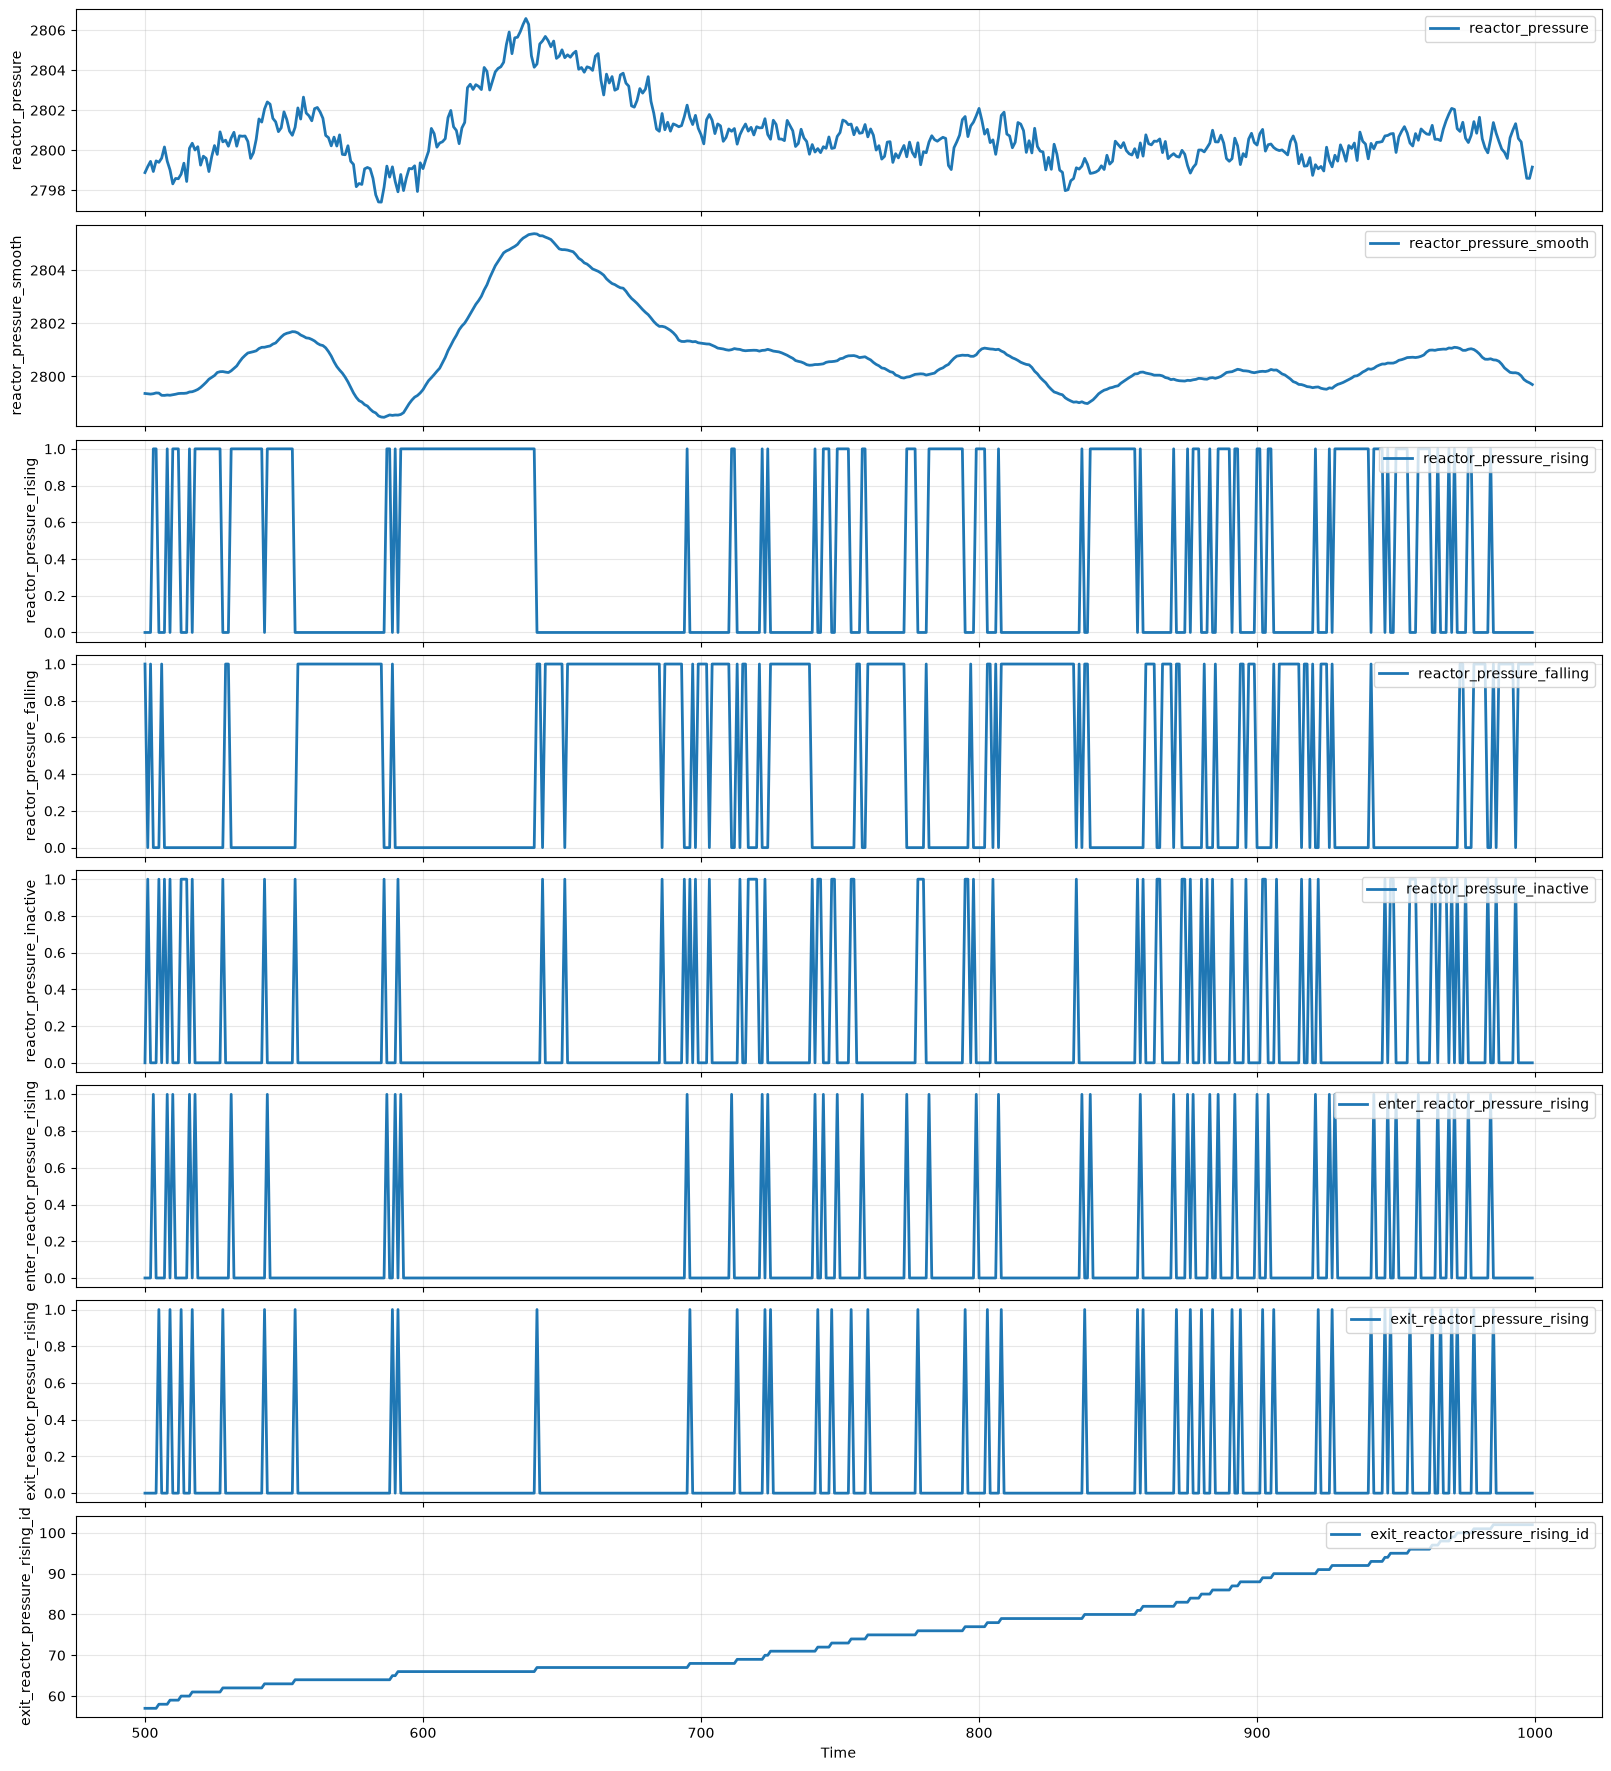

In [2]:
fg.plot(df[500:1000], [['reactor_pressure'],
                              ['reactor_pressure_smooth'],
                              ['reactor_pressure_rising'],
                              ['reactor_pressure_falling'],
                              ['reactor_pressure_inactive'],
                              ['enter_reactor_pressure_rising'],
                              ['exit_reactor_pressure_rising'],
                              ['exit_reactor_pressure_rising_id']
                             ]
)

In [6]:
summarydf = (
    df.groupby("exit_reactor_pressure_rising_id")
    .agg(
        start_index=("sample_index", "min"),
        end_index=("sample_index", "max"),
        start_time=("time_hours", "min"),
        end_time=("time_hours", "max"),

        reactor_pressure_rising_samples=(
            "reactor_pressure_rising", "sum"
        ),
        reactor_pressure_falling_samples=(
            "reactor_pressure_falling", "sum"
        ),
        reactor_pressure_inactive_samples=(
            "reactor_pressure_inactive", "sum"
        ),

        enter_rising_count=(
            "enter_reactor_pressure_rising", "sum"
        ),
        exit_rising_count=(
            "exit_reactor_pressure_rising", "sum"
        ),
    )
)

summarydf["duration_hours"] = (
    summarydf["end_time"] - summarydf["start_time"]
)

In [ ]:
summarydf

,start_index,end_index,start_time,end_time,reactor_pressure_rising_samples,reactor_pressure_falling_samples,reactor_pressure_inactive_samples,enter_rising_count,exit_rising_count,duration_hours
exit_reactor_pressure_rising_id,,,,,,,,,,
0,0,23,0.000000,0.383333,13,0,0,1,0,0.383333
1,24,28,0.400000,0.466667,3,0,2,1,1,0.066667
2,29,30,0.483333,0.500000,1,0,1,1,1,0.016667
3,31,33,0.516667,0.550000,2,0,1,1,1,0.033333
4,34,47,0.566667,0.783333,3,10,1,1,1,0.216667
...,...,...,...,...,...,...,...,...,...,...
275,2945,2946,49.083333,49.100000,1,1,0,1,1,0.016667
276,2947,2949,49.116667,49.150000,1,0,2,1,1,0.033333
277,2950,2988,49.166667,49.800000,4,31,4,1,1,0.633333
